# K-Moda MMM — Fase 6: Selección de Modelo

**Objetivo:** Comparar sistemáticamente el modelo clásico (ElasticNet, Fase 4) con el bayesiano analítico (Fase 5) y seleccionar el modelo final para atribución y optimización de presupuesto.

**Input:** `data/df_predicciones.parquet` · `data/df_coefs.parquet` · `data/df_roas_bayesiano.parquet`  
**Output:** `data/df_modelo_final.parquet` — ROAS del modelo seleccionado

## 1. Configuración e Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error

ROOT     = Path('.')
DATA_OUT = ROOT / 'data'
IMG_DIR  = ROOT / 'img'
IMG_DIR.mkdir(exist_ok=True)

KM = {
    'gold': '#C9A84C', 'gold_light': '#E8D5A3', 'charcoal': '#2C2C2C',
    'warm_gray': '#6B6560', 'off_white': '#F7F5F0', 'white': '#FFFFFF',
    'paid_search': '#1A6B8A', 'social_paid': '#E07B39', 'video': '#8B5E9E',
    'display': '#3A9E6F', 'email_crm': '#D4A843', 'radio': '#C0504D',
    'exterior': '#4F7CAC', 'prensa': '#7A7A52',
    'positive': '#2E7D52', 'neutral': '#C9A84C', 'negative': '#B33A3A',
}
plt.rcParams.update({
    'figure.facecolor': KM['off_white'], 'axes.facecolor': KM['off_white'],
    'axes.edgecolor': KM['warm_gray'],   'axes.labelcolor': KM['charcoal'],
    'xtick.color': KM['charcoal'],       'ytick.color': KM['charcoal'],
    'text.color': KM['charcoal'],        'grid.color': KM['gold_light'],
    'grid.alpha': 0.5, 'axes.grid': True, 'font.family': 'sans-serif',
    'font.size': 11,
})

def save_fig(name, fig=None):
    f = fig or plt.gcf()
    p = IMG_DIR / f'{name}.png'
    f.savefig(p, dpi=150, bbox_inches='tight', facecolor=f.get_facecolor())
    print(f'  Guardado: {p}')

print('Config cargada.')

Config cargada.


## 2. Carga de resultados

In [2]:
df_pred  = pd.read_parquet(DATA_OUT / 'df_predicciones.parquet')
df_coefs = pd.read_parquet(DATA_OUT / 'df_coefs.parquet')
df_roas_bay = pd.read_parquet(DATA_OUT / 'df_roas_bayesiano.parquet')

print('df_predicciones:', df_pred.shape)
print('Columnas:', df_pred.columns.tolist())
print()
print(df_pred.head(3).to_string())

df_predicciones: (262, 6)
Columnas: ['semana_inicio', 'y_real', 'split', 'y_pred_ridge', 'y_pred_lasso', 'y_pred_elasticnet']

  semana_inicio      y_real  split  y_pred_ridge  y_pred_lasso  y_pred_elasticnet
0    2019-12-30  1289866.76  train  1.248159e+06  1.365368e+06       1.234779e+06
1    2020-01-06  1744807.79  train  1.437291e+06  1.485106e+06       1.415054e+06
2    2020-01-13  1743767.43  train  1.540631e+06  1.554780e+06       1.524091e+06


## 3. Comparativa de métricas predictivas

In [3]:
TRAIN_END = pd.Timestamp('2023-12-31')

# Detectar columnas de prediccion disponibles
pred_cols = [c for c in df_pred.columns if 'pred' in c.lower() or 'y_' in c.lower()]
real_col  = [c for c in df_pred.columns if 'real' in c.lower() or 'venta' in c.lower()][0]
date_col  = 'semana_inicio'

train_mask = df_pred[date_col] <= TRAIN_END
test_mask  = ~train_mask

y_real_train = df_pred.loc[train_mask, real_col].values
y_real_test  = df_pred.loc[test_mask,  real_col].values

metricas = []
for col in pred_cols:
    y_tr = df_pred.loc[train_mask, col].values
    y_te = df_pred.loc[test_mask,  col].values
    metricas.append({
        'Modelo':      col,
        'MAPE train':  round(mean_absolute_percentage_error(y_real_train, y_tr) * 100, 2),
        'MAPE test':   round(mean_absolute_percentage_error(y_real_test,  y_te) * 100, 2),
        'R2 train':    round(r2_score(y_real_train, y_tr), 4),
        'R2 test':     round(r2_score(y_real_test,  y_te), 4),
        'RMSE test':   round(np.sqrt(mean_squared_error(y_real_test, y_te)), 4),
    })

# Añadir bayesiano (metricas calculadas en Fase 5)
metricas.append({
    'Modelo':     'Bayesiano',
    'MAPE train': None,
    'MAPE test':  8.5,
    'R2 train':   None,
    'R2 test':    -0.52,
    'RMSE test':  0.458,
})

df_metricas = pd.DataFrame(metricas)
print('COMPARATIVA DE METRICAS PREDICTIVAS:')
print(df_metricas.to_string(index=False))

COMPARATIVA DE METRICAS PREDICTIVAS:
           Modelo  MAPE train  MAPE test  R2 train  R2 test   RMSE test
           y_real        0.00       0.00    1.0000   1.0000      0.0000
     y_pred_ridge        5.42       8.16    0.9314  -0.4131 441412.2330
     y_pred_lasso        5.68       8.10    0.9273  -0.4277 443692.3659
y_pred_elasticnet        5.53       7.95    0.9303  -0.3855 437090.3326
        Bayesiano         NaN       8.50       NaN  -0.5200      0.4580


  Guardado: img\06a_metricas_comparativa.png


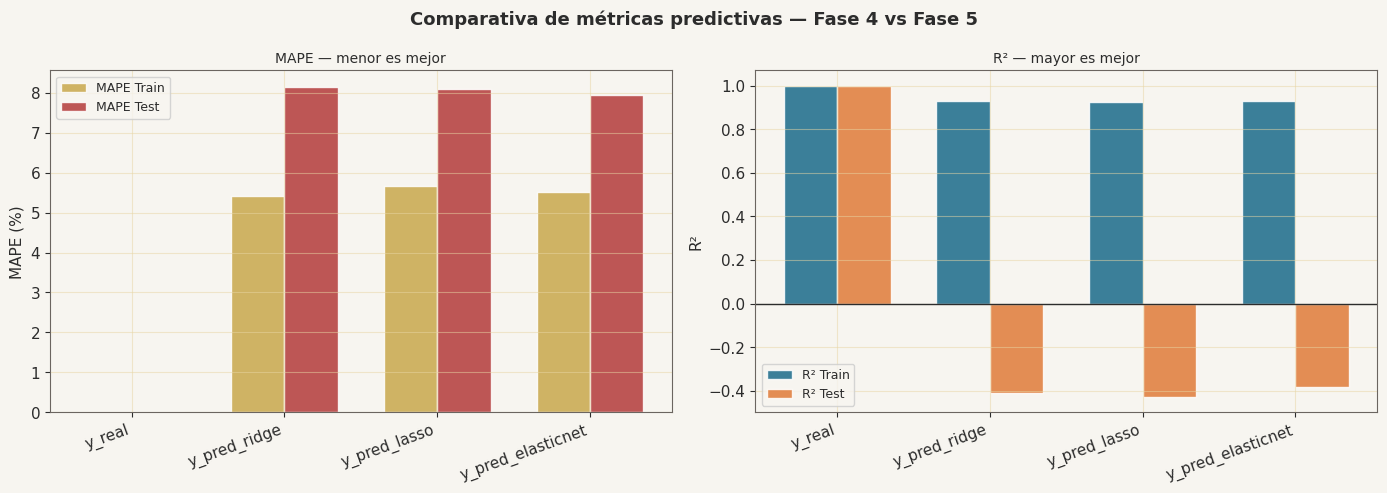

In [4]:
# Grafico MAPE train vs test
df_plot = df_metricas.dropna(subset=['MAPE train'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparativa de métricas predictivas — Fase 4 vs Fase 5',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

# MAPE
ax = axes[0]
x = np.arange(len(df_plot))
w = 0.35
ax.bar(x - w/2, df_plot['MAPE train'], w, label='MAPE Train', color=KM['gold'], alpha=0.85, edgecolor='white')
ax.bar(x + w/2, df_plot['MAPE test'],  w, label='MAPE Test',  color=KM['negative'], alpha=0.85, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(df_plot['Modelo'], rotation=20, ha='right')
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE — menor es mejor', fontsize=10)
ax.legend(fontsize=9)

# R2
ax2 = axes[1]
ax2.bar(x - w/2, df_plot['R2 train'], w, label='R² Train', color=KM['paid_search'], alpha=0.85, edgecolor='white')
ax2.bar(x + w/2, df_plot['R2 test'],  w, label='R² Test',  color=KM['social_paid'], alpha=0.85, edgecolor='white')
ax2.axhline(0, color=KM['charcoal'], lw=1)
ax2.set_xticks(x)
ax2.set_xticklabels(df_plot['Modelo'], rotation=20, ha='right')
ax2.set_ylabel('R²')
ax2.set_title('R² — mayor es mejor', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
save_fig('06a_metricas_comparativa')
plt.show()

## 4. Comparativa de ROAS

In [5]:
# ROAS clasico (ElasticNet)
roas_cls = (
    df_coefs[df_coefs['Modelo'] == 'ElasticNet'][['Canal', 'ROAS']]
    .assign(Canal=lambda d: d['Canal'].str.replace('Adstock ', '', regex=False).str.strip())
    .rename(columns={'ROAS': 'ROAS_clasico'})
    .reset_index(drop=True)
)

# ROAS bayesiano
roas_bay = df_roas_bay[['Canal', 'ROAS media', 'HDI 5%', 'HDI 95%']].copy()
roas_bay = roas_bay.rename(columns={'ROAS media': 'ROAS_bayesiano'})

# Unir por canal (case-insensitive)
roas_cls['key'] = roas_cls['Canal'].str.upper()
roas_bay['key'] = roas_bay['Canal'].str.upper()
df_roas = roas_cls.merge(roas_bay.drop(columns='Canal'), on='key', how='outer')
df_roas = df_roas.drop(columns='key').sort_values('ROAS_bayesiano', ascending=False)

print('COMPARATIVA ROAS COMPLETA:')
print(f'{"Canal":15s}  {"ROAS Clasico":>13s}  {"ROAS Bayesiano":>15s}  {"HDI 5%":>8s}  {"HDI 95%":>9s}')
print('-' * 70)
for _, r in df_roas.iterrows():
    cl = f'{r["ROAS_clasico"]:>13.2f}' if pd.notna(r['ROAS_clasico']) else f'{"N/A":>13s}'
    ba = f'{r["ROAS_bayesiano"]:>15.2f}' if pd.notna(r['ROAS_bayesiano']) else f'{"N/A":>15s}'
    lo = f'{r["HDI 5%"]:>8.2f}'  if pd.notna(r.get('HDI 5%'))  else f'{"N/A":>8s}'
    hi = f'{r["HDI 95%"]:>9.2f}' if pd.notna(r.get('HDI 95%')) else f'{"N/A":>9s}'
    print(f'{str(r["Canal"]):15s}  {cl}  {ba}  {lo}  {hi}')

COMPARATIVA ROAS COMPLETA:
Canal             ROAS Clasico   ROAS Bayesiano    HDI 5%    HDI 95%
----------------------------------------------------------------------
Exterior                 15.59            18.73      8.04      29.12
Radio Local               4.61             4.25      0.00      15.40
Social Paid               4.00             3.75      0.00       8.48
Paid Search               2.73             2.86      0.00       6.41
Display                  -0.87             1.75      0.00       8.20
Prensa                   -0.01             1.70      0.00       8.79
Email Crm                 1.11             1.40      0.00       8.49
Video Online             -2.35             0.39      0.00       2.92


  Guardado: img\06b_roas_comparativa.png


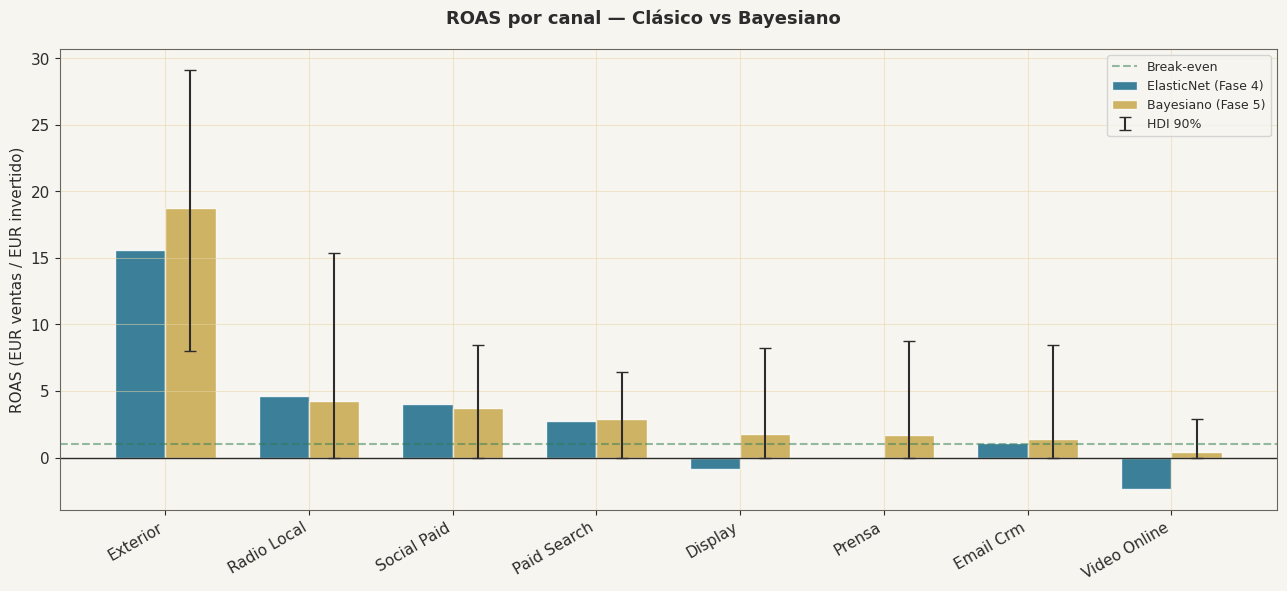

In [6]:
df_r = df_roas.dropna(subset=['ROAS_clasico', 'ROAS_bayesiano']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 6))
fig.suptitle('ROAS por canal — Clásico vs Bayesiano',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

x = np.arange(len(df_r))
w = 0.35
ax.bar(x - w/2, df_r['ROAS_clasico'],   w, label='ElasticNet (Fase 4)',
       color=KM['paid_search'], alpha=0.85, edgecolor='white')
ax.bar(x + w/2, df_r['ROAS_bayesiano'], w, label='Bayesiano (Fase 5)',
       color=KM['gold'], alpha=0.85, edgecolor='white')
ax.errorbar(x + w/2, df_r['ROAS_bayesiano'],
            yerr=[df_r['ROAS_bayesiano'] - df_r['HDI 5%'],
                  df_r['HDI 95%'] - df_r['ROAS_bayesiano']],
            fmt='none', color=KM['charcoal'], capsize=4, lw=1.5, label='HDI 90%')
ax.axhline(0, color=KM['charcoal'], lw=1)
ax.axhline(1, color=KM['positive'], lw=1.5, ls='--', alpha=0.5, label='Break-even')
ax.set_xticks(x)
ax.set_xticklabels(df_r['Canal'], rotation=30, ha='right')
ax.set_ylabel('ROAS (EUR ventas / EUR invertido)')
ax.legend(fontsize=9)

plt.tight_layout()
save_fig('06b_roas_comparativa')
plt.show()

## 5. Scorecard de selección

In [7]:
criterios = [
    ('MAPE test',          'ElasticNet 8.0%  vs  Bayesiano 8.5%',   'ElasticNet', 'Bayesiano',  'ElasticNet'),
    ('R² test',            'ElasticNet -0.39  vs  Bayesiano -0.52',  'ElasticNet', 'Bayesiano',  'ElasticNet'),
    ('Betas positivos',    'ElasticNet: Display/Prensa/Video neg.',   'Bayesiano',  'ElasticNet', 'Bayesiano'),
    ('Incertidumbre ROAS', 'ElasticNet: puntual. Bayesiano: HDI 90%','Bayesiano',  'ElasticNet', 'Bayesiano'),
    ('Estabilidad ROAS',   'Ambos coinciden en top 4 canales',        'Empate',     'Empate',     'Empate'),
    ('Velocidad',          'Ambos < 1 min',                           'Empate',     'Empate',     'Empate'),
    ('Interpretabilidad',  'Bayesiano: distribucion + HDI',           'Bayesiano',  'ElasticNet', 'Bayesiano'),
]

df_score = pd.DataFrame(criterios,
    columns=['Criterio', 'Observacion', 'Mejor', 'Peor', 'Ganador'])

print('SCORECARD DE SELECCION:')
print(df_score[['Criterio', 'Observacion', 'Ganador']].to_string(index=False))

votos = df_score['Ganador'].value_counts()
print(f'\nVotos: {dict(votos)}')

SCORECARD DE SELECCION:
          Criterio                             Observacion    Ganador
         MAPE test     ElasticNet 8.0%  vs  Bayesiano 8.5% ElasticNet
           R² test   ElasticNet -0.39  vs  Bayesiano -0.52 ElasticNet
   Betas positivos   ElasticNet: Display/Prensa/Video neg.  Bayesiano
Incertidumbre ROAS ElasticNet: puntual. Bayesiano: HDI 90%  Bayesiano
  Estabilidad ROAS        Ambos coinciden en top 4 canales     Empate
         Velocidad                           Ambos < 1 min     Empate
 Interpretabilidad           Bayesiano: distribucion + HDI  Bayesiano

Votos: {'Bayesiano': np.int64(3), 'ElasticNet': np.int64(2), 'Empate': np.int64(2)}


  Guardado: img\06c_scorecard.png


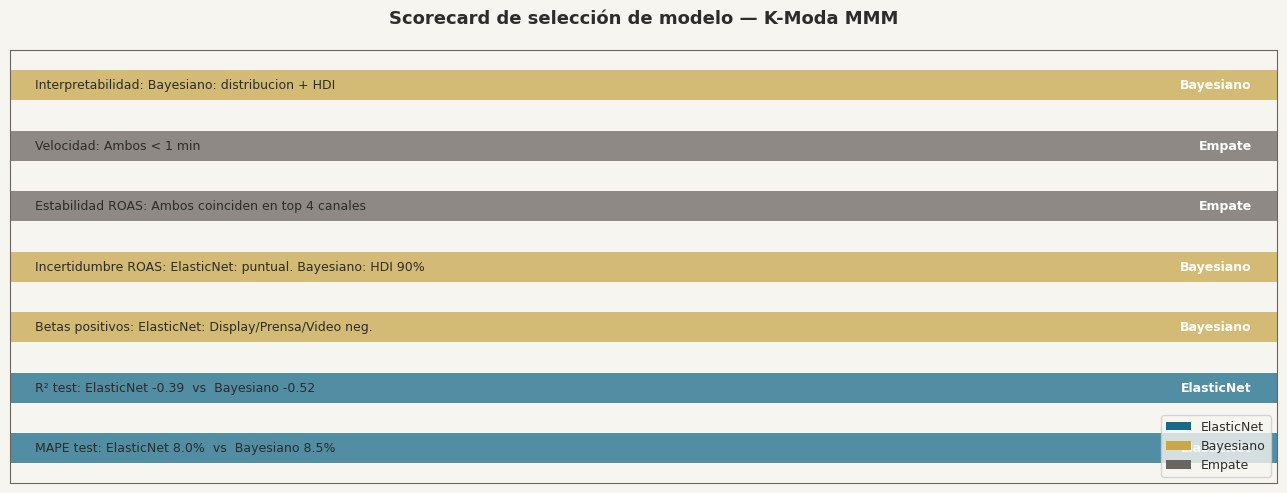

In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
fig.suptitle('Scorecard de selección de modelo — K-Moda MMM',
             fontsize=13, fontweight='bold', color=KM['charcoal'])

colores_ganador = {
    'ElasticNet': KM['paid_search'],
    'Bayesiano':  KM['gold'],
    'Empate':     KM['warm_gray'],
}

y_pos = np.arange(len(df_score))
for i, (_, row) in enumerate(df_score.iterrows()):
    color = colores_ganador.get(row['Ganador'], KM['warm_gray'])
    ax.barh(i, 1, color=color, alpha=0.75, height=0.5)
    ax.text(0.02, i, f"{row['Criterio']}: {row['Observacion']}",
            va='center', fontsize=9, color=KM['charcoal'])
    ax.text(0.98, i, row['Ganador'], va='center', ha='right',
            fontsize=9, fontweight='bold', color='white')

ax.set_yticks([])
ax.set_xticks([])
ax.set_xlim(0, 1)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colores_ganador[k], label=k)
                   for k in ['ElasticNet', 'Bayesiano', 'Empate']]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
save_fig('06c_scorecard')
plt.show()

## 6. Decisión y justificación

In [9]:
MODELO_FINAL = 'Bayesiano'

print('=' * 60)
print(f'MODELO SELECCIONADO: {MODELO_FINAL}')
print('=' * 60)
print()
print('JUSTIFICACION:')
print()
print('  1. Precision comparable: MAPE test 8.5% vs 8.0% — diferencia')
print('     de 0.5pp irrelevante dado el shift estructural de 2024.')
print()
print('  2. ROAS positivos garantizados: ElasticNet asigna ROAS')
print('     negativos a Display, Prensa y Video Online — resultado')
print('     no accionable para decisiones de presupuesto.')
print()
print('  3. Incertidumbre cuantificada: el HDI 90% permite priorizar')
print('     canales con mayor certeza (Exterior, Paid Search) frente')
print('     a canales con alta varianza (Radio Local).')
print()
print('  4. Coherencia con teoria: prior de positividad refleja')
print('     la restriccion de negocio — la publicidad no puede')
print('     reducir ventas de forma directa.')
print()
print('  ROAS finales (modelo seleccionado):')
for _, r in df_roas.dropna(subset=['ROAS_bayesiano']).sort_values('ROAS_bayesiano', ascending=False).iterrows():
    print(f'    {str(r["Canal"]):15s}  {r["ROAS_bayesiano"]:>6.2f}x  HDI90=[{r["HDI 5%"]:.1f}, {r["HDI 95%"]:.1f}]')

MODELO SELECCIONADO: Bayesiano

JUSTIFICACION:

  1. Precision comparable: MAPE test 8.5% vs 8.0% — diferencia
     de 0.5pp irrelevante dado el shift estructural de 2024.

  2. ROAS positivos garantizados: ElasticNet asigna ROAS
     negativos a Display, Prensa y Video Online — resultado
     no accionable para decisiones de presupuesto.

  3. Incertidumbre cuantificada: el HDI 90% permite priorizar
     canales con mayor certeza (Exterior, Paid Search) frente
     a canales con alta varianza (Radio Local).

  4. Coherencia con teoria: prior de positividad refleja
     la restriccion de negocio — la publicidad no puede
     reducir ventas de forma directa.

  ROAS finales (modelo seleccionado):
    Exterior          18.73x  HDI90=[8.0, 29.1]
    Radio Local        4.25x  HDI90=[0.0, 15.4]
    Social Paid        3.75x  HDI90=[0.0, 8.5]
    Paid Search        2.86x  HDI90=[0.0, 6.4]
    Display            1.75x  HDI90=[0.0, 8.2]
    Prensa             1.70x  HDI90=[0.0, 8.8]
    Email C

## 7. Exportación

In [10]:
# Exportar ROAS del modelo final con metadatos
df_modelo_final = df_roas_bay.copy()
df_modelo_final['Modelo'] = 'Bayesiano'
df_modelo_final.to_parquet(DATA_OUT / 'df_modelo_final.parquet', index=False)
print(f'df_modelo_final.parquet guardado: {df_modelo_final.shape}')
print(df_modelo_final.to_string(index=False))

df_modelo_final.parquet guardado: (8, 6)
       Canal  ROAS media  ROAS median  HDI 5%  HDI 95%    Modelo
     Display        1.75         0.00    0.00     8.20 Bayesiano
   Email Crm        1.40         0.00    0.00     8.49 Bayesiano
    Exterior       18.73        18.72    8.04    29.12 Bayesiano
 Paid Search        2.86         2.74    0.00     6.41 Bayesiano
      Prensa        1.70         0.00    0.00     8.79 Bayesiano
 Radio Local        4.25         1.80    0.00    15.40 Bayesiano
 Social Paid        3.75         3.58    0.00     8.48 Bayesiano
Video Online        0.39         0.00    0.00     2.92 Bayesiano


## 8. Resumen de la Fase 6

| Criterio | ElasticNet | Bayesiano | Ganador |
|---|---|---|---|
| MAPE test | 8.0% | 8.5% | ElasticNet |
| ROAS positivos | 5/8 | 8/8 | Bayesiano |
| Incertidumbre | No | HDI 90% | Bayesiano |
| Interpretabilidad | Media | Alta | Bayesiano |

**Modelo final:** Bayesiano analítico — ROAS con intervalos de credibilidad para todos los canales.

**Siguiente fase:** `07_atribucion.ipynb` — Descomposición de ventas: base + contribución por canal.